In [1]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [44]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
import seaborn as sns
from helper import *
from plots import *
import random

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

# Загружаем датасет в память
df = pd.read_csv("diamonds.csv", index_col=0)
df_preprocessed = df.copy()
# Дубликаты
df_preprocessed.drop_duplicates(inplace=True)
# Удаление строк, где x/y/z = 0
df_preprocessed = df_preprocessed[(df_preprocessed[["x", "y", "z"]] != 0).all(axis=1)]
# делим данные на признаки и таргет
X, y = divide_data(df_preprocessed, "price")
# Разбиваем данные на train, val и test с соотношением 60-20-20
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(
    X, y, 
    train_size=0.6, 
    val_size=0.2, 
    test_size=0.2, 
    random_state=SEED,
)
X_train_preprocessed = X_train.copy()

categorical_cols = ["cut", "color", "clarity"]
category_orders = [
    ["Fair", "Good", "Very Good", "Premium", "Ideal"], # cut
    ["D", "E", "F", "G", "H", "I", "J"], # color
    ["IF", "VVS1", "VVS2", "VS1", "VS2", "SI1", "SI2", "I1"], # clarity
]

preprocessor = Pipeline([    
    ("transformations", ColumnTransformer(
        [("encoder", OrdinalEncoder(categories=category_orders), categorical_cols)],
        remainder="passthrough",  # числовые колонки передаются без изменений
        verbose_feature_names_out=False
    ))
])

# Устанавливаем вывод в формате pandas DataFrame (для sklearn версии 1.0 и выше)
preprocessor.set_output(transform="pandas")
# обучаем и применяем наш пайплайн к тренировочной выборке
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_train_preprocessed = pd.DataFrame(X_train_preprocessed, index=X_train.index)

X_train_preprocessed

,cut,color,clarity,carat,depth,table,x,y,z
15430,2.0,4.0,3.0,1.20,62.0,57.0,6.77,6.81,4.21
52670,4.0,3.0,4.0,0.80,60.1,57.0,6.05,6.02,3.63
43144,2.0,4.0,4.0,0.52,63.5,58.0,5.08,5.09,3.23
32503,2.0,2.0,5.0,0.40,63.3,57.0,4.68,4.73,2.98
33373,2.0,3.0,4.0,0.41,61.7,61.0,4.70,4.74,2.91
...,...,...,...,...,...,...,...,...,...
11882,3.0,4.0,3.0,1.08,62.5,60.0,6.55,6.51,4.08
44832,3.0,1.0,5.0,0.51,61.7,59.0,5.12,5.09,3.15
3687,2.0,5.0,3.0,0.90,62.6,58.0,6.14,6.17,3.85
676,4.0,0.0,2.0,0.54,61.5,55.0,5.25,5.29,3.24


## 6. Построение базовой модели (baseline)
Сейчас наша задача построить базовую модель, от которой мы будем отталкиваться в дальнейшем для применения улучшений. Здесь мы намеренно не трогаем большую часть гиперпараметров моделей и оставляем значения по умолчанию. Подбор этих параметров будет осуществляться позже на финальных стадиях. Мы также не совершали преобразований с данными, направленных на улучшение, поскольку пока что нам не с чем сравнивать наш результат. 

In [4]:
# применяем уже обученный пайплайн к тестовой выборке.
# Очень важно: здесь уже вызываем transform без fit, чтобы не допустить обучения на тестовых данных
X_val_preprocessed = preprocessor.transform(X_val)

In [5]:
X_val_preprocessed

,cut,color,clarity,carat,depth,table,x,y,z
25371,4.0,2.0,2.0,0.28,61.4,57.0,4.20,4.24,2.59
2303,1.0,1.0,4.0,0.74,63.9,54.0,5.77,5.81,3.70
13476,3.0,3.0,6.0,1.22,60.2,58.0,6.92,6.90,4.16
43791,2.0,2.0,5.0,0.56,63.2,56.0,5.29,5.24,3.33
45413,4.0,3.0,3.0,0.51,61.7,56.0,5.10,5.20,3.18
...,...,...,...,...,...,...,...,...,...
50388,1.0,3.0,5.0,0.71,62.3,56.0,5.68,5.72,3.55
41281,2.0,1.0,0.0,0.31,61.5,59.0,4.34,4.37,2.68
40734,4.0,2.0,6.0,0.54,61.2,56.0,5.27,5.28,3.23
2145,4.0,1.0,1.0,0.52,61.8,55.0,5.20,5.19,3.21


In [6]:
X_val_preprocessed.info()

<class 'pandas.DataFrame'>
Index: 10755 entries, 25371 to 45149
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cut      10755 non-null  float64
 1   color    10755 non-null  float64
 2   clarity  10755 non-null  float64
 3   carat    10755 non-null  float64
 4   depth    10755 non-null  float64
 5   table    10755 non-null  float64
 6   x        10755 non-null  float64
 7   y        10755 non-null  float64
 8   z        10755 non-null  float64
dtypes: float64(9)
memory usage: 840.2 KB


In [7]:
X_val_preprocessed.isnull().sum()

cut        0
color      0
clarity    0
carat      0
depth      0
table      0
x          0
y          0
z          0
dtype: int64

In [8]:
feature_names = X_val_preprocessed.columns.to_list()

### 6.1 Dummy Classifier
Для начала попробуем использовать глупый классификатор, который всегда предсказывает только самый частый класс и посмотреть на значение метрик. Это даст нам понимание, от какого нижнего порога метрик нам отталкиваться и с чем сравнивать наши модели.

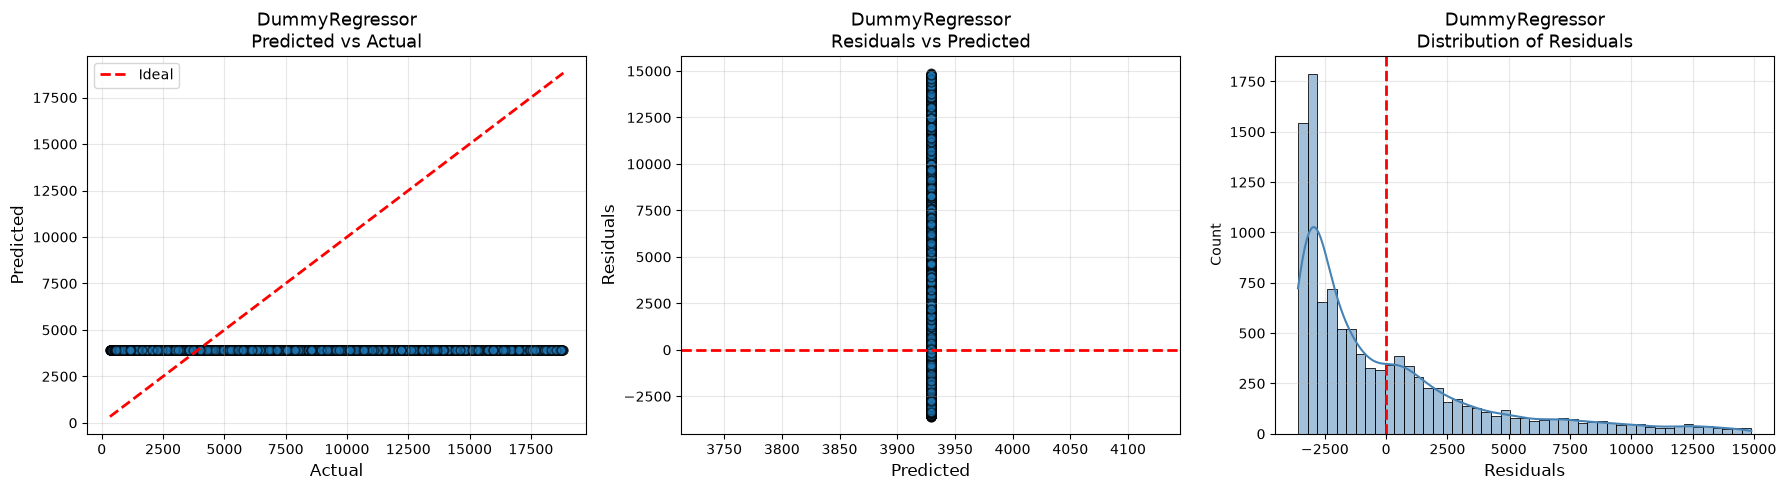

 Regression Report: DummyRegressor
MAE   : 3038.2705
MSE   : 15960929.7594
RMSE  : 3995.1132
R²    : -0.0000
MAPE  : 187.61%
MedAE : 2782.9814


In [10]:
# Задаем и обучаем модель
dummy_classifier = DummyRegressor(strategy="mean")
dummy_classifier.fit(X_train_preprocessed, y_train)

# Получаем предсказания
y_pred = dummy_classifier.predict(X_val_preprocessed)

# Считаем метрики для модели и выводим графики
dummy_classifier_metrics = evaluate_regression(
    y_test=y_val,
    y_pred=y_pred,
    model_name="DummyRegressor"
)

Сейчас модель просто угадывает среднее и не несёт никакой предсказательной силы.

### 6.2 Логистическая регрессия

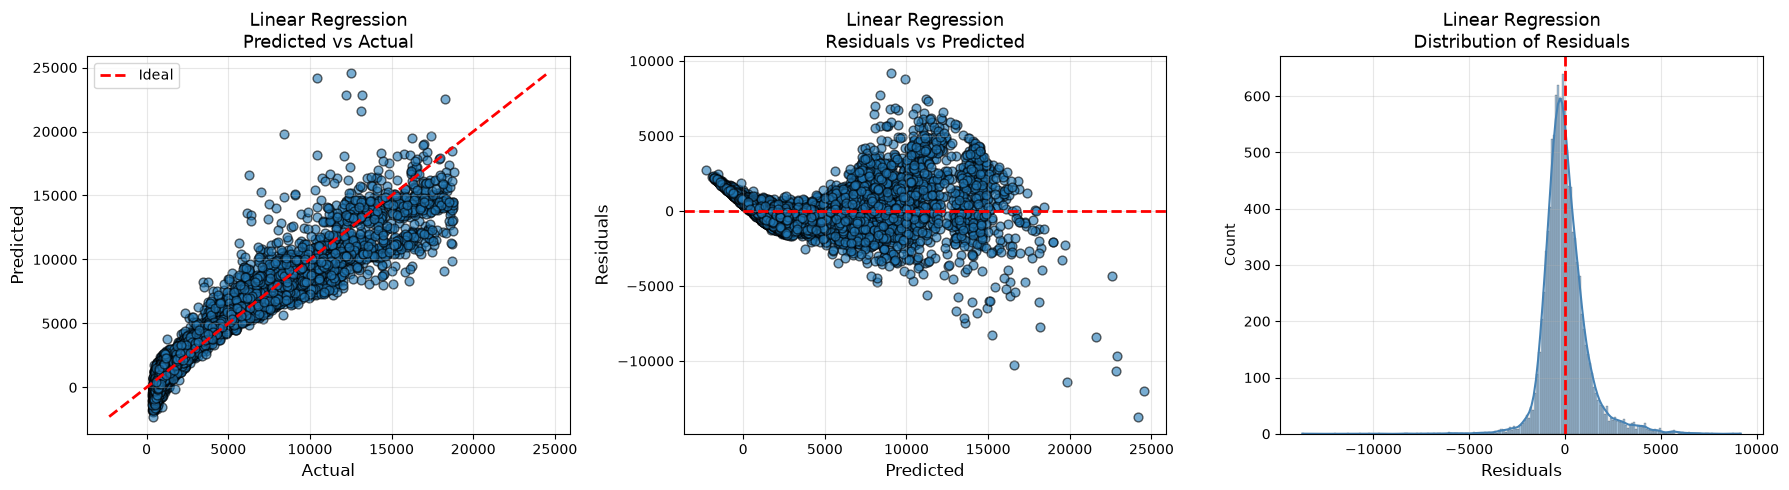

 Regression Report: Linear Regression
MAE   : 802.9022
MSE   : 1451520.3081
RMSE  : 1204.7906
R²    : 0.9091
MAPE  : 43.01%
MedAE : 574.6668


In [12]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_preprocessed, y_train)

y_pred = lin_reg.predict(X_val_preprocessed)

lin_reg_metrics = evaluate_regression(
    y_test=y_val,
    y_pred=y_pred,
    model_name="Linear Regression"
)

Неплохие результаты для линейной регресии с базовыми признаками: 
- Predicted vs Actual: Точки хорошо ложатся вдоль идеальной линии, однако наблюдается разброс при предсказании цены для дорогих камней 
- Residuals vs Predicted: Остатки в целом центрированы около нуля, но разброс ошибок растёт с увеличением предсказанной цены
- Distribution of Residuals: Распределение ошибок близко к нормальному

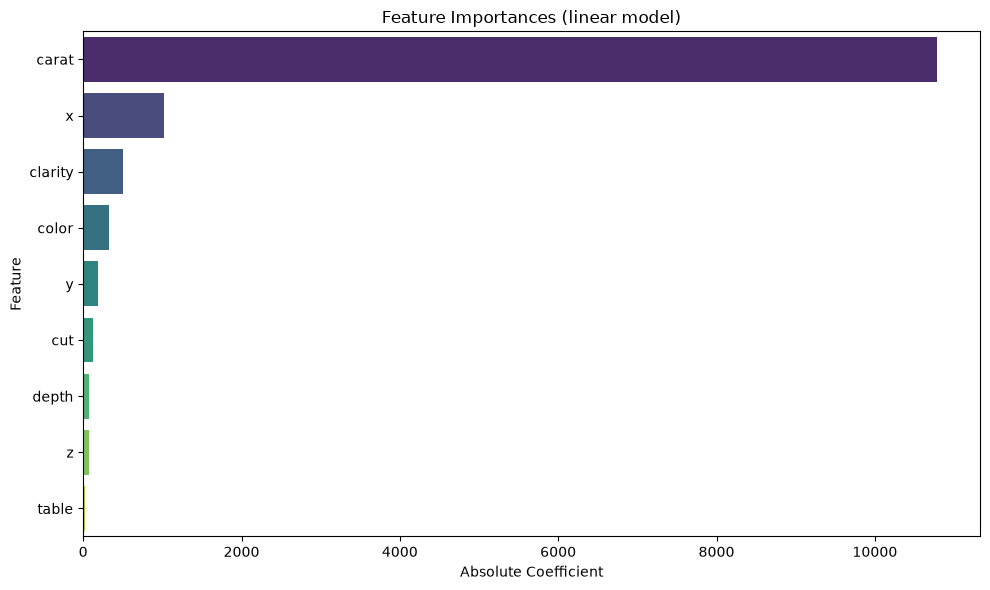

,Feature,Importance
3,carat,10788.384482
6,x,1026.301596
2,clarity,498.508412
1,color,320.955262
7,y,186.918167
0,cut,120.735899
4,depth,78.089355
8,z,74.984570
5,table,25.794991


In [13]:
# Построим гистограмму важностей для каждой фичи
plot_feature_importance(lin_reg, feature_names)

По важности признаков на первом месте оказался вес в каратах

### 6.3 Дерево решений

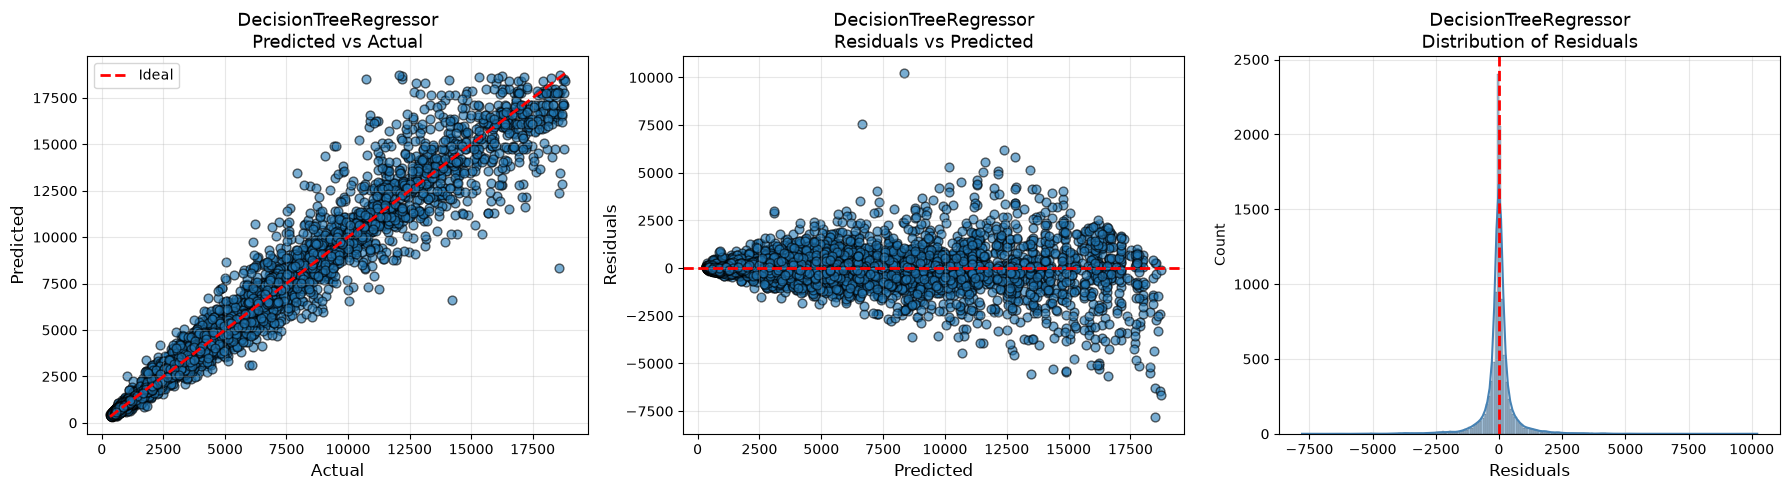

 Regression Report: DecisionTreeRegressor
MAE   : 338.6412
MSE   : 493874.0039
RMSE  : 702.7617
R²    : 0.9691
MAPE  : 8.23%
MedAE : 123.0000


In [33]:
decision_tree = DecisionTreeRegressor(random_state=SEED, max_depth=14)
decision_tree.fit(X_train_preprocessed, y_train)

y_pred = decision_tree.predict(X_val_preprocessed)

decision_tree_metrics = evaluate_regression(
    y_test=y_val,
    y_pred=y_pred,
    model_name="DecisionTreeRegressor"
)

Значительное уменьшение ошибок по метрикам и графикам

- Predicted vs Actual: Точки хорошо ложатся вдоль идеальной линии, разброс заметно меньше, чем у линейной регрессии.
- Residuals vs Predicted: Остатки в целом центрированы около нуля, но разброс ошибок растёт с увеличением предсказанной цены (гетероскедастичность сохраняется).
- Distribution of Residuals: Распределение ошибок близко к нормальному и сильно сконцентрировано около нуля.

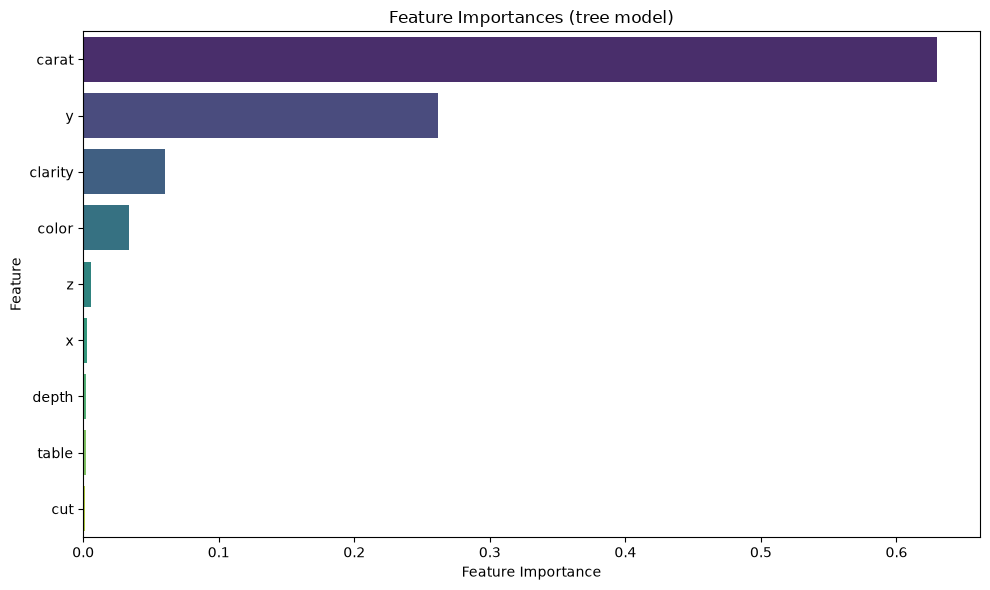

,Feature,Importance
3,carat,0.630103
7,y,0.261687
2,clarity,0.060687
1,color,0.033794
8,z,0.005492
6,x,0.002820
4,depth,0.002235
5,table,0.001732
0,cut,0.001449


In [26]:
plot_feature_importance(decision_tree, feature_names)

Помимо веса в каратах начали больше использоваться признаки ширина и чистота бриллианта

### 6.4 Случайный лес

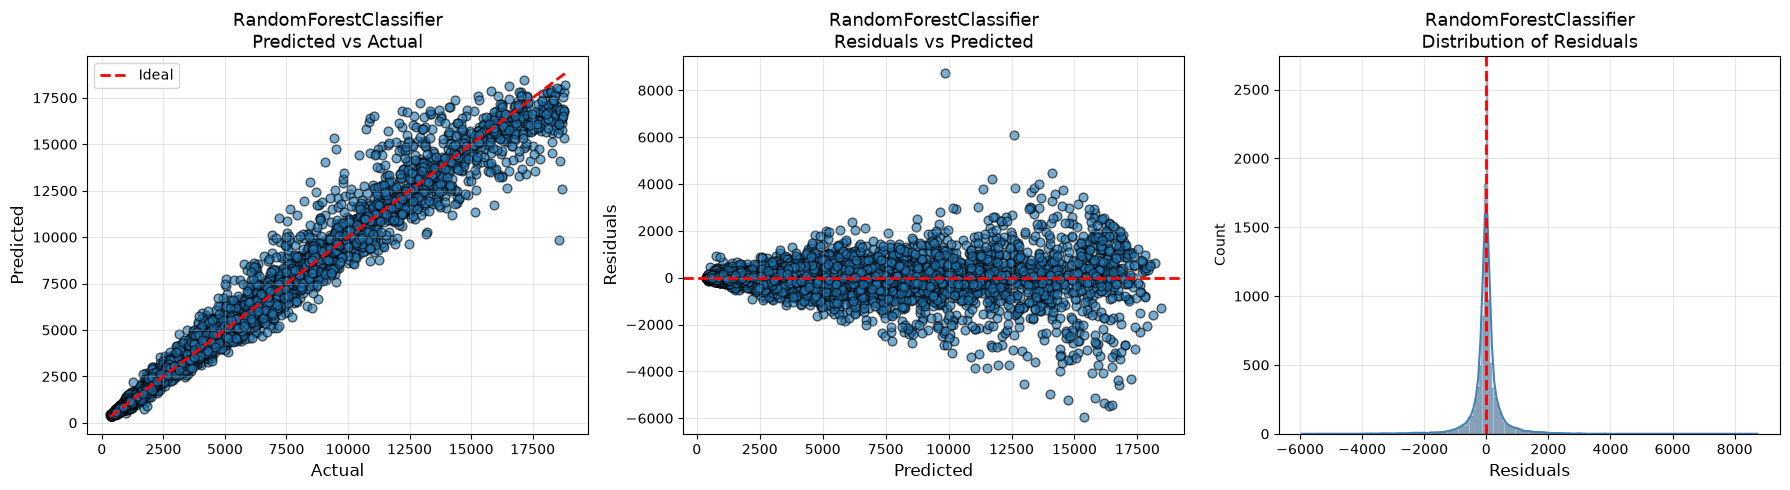

 Regression Report: RandomForestClassifier
MAE   : 275.5116
MSE   : 321500.8238
RMSE  : 567.0104
R²    : 0.9799
MAPE  : 6.56%
MedAE : 100.9900


In [35]:
# Train your model
random_forest = RandomForestRegressor(random_state=SEED)
random_forest.fit(X_train_preprocessed, y_train)

# Get predictions
y_pred = random_forest.predict(X_val_preprocessed)

# Evaluate
random_forest_metrics = evaluate_regression(
    y_test=y_val,
    y_pred=y_pred,
    model_name="RandomForestClassifier"
)

Значительное уменьшение MAE и RMSE (было 339 / 703)

- Predicted vs Actual: Точки очень хорошо ложатся вдоль идеальной линии, разброс ещё меньше, чем у Decision Tree (заметно на больших ценах).
- Residuals vs Predicted: Остатки в целом центрированы около нуля, разброс ошибок продолжает расти с увеличением предсказанной цены.
- Distribution of Residuals: Распределение ошибок близко к нормальному и сильно сконцентрировано около нуля.

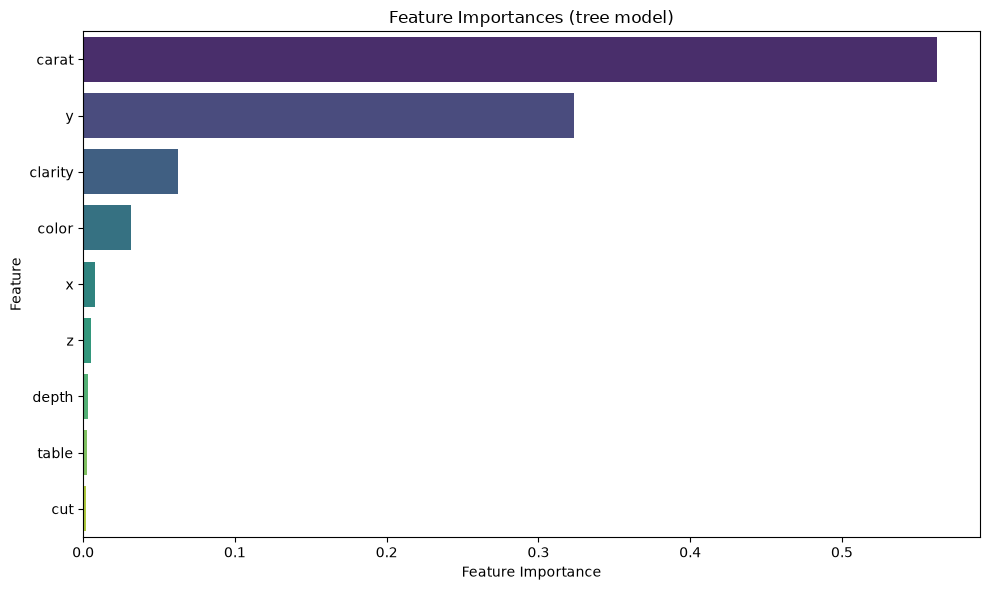

,Feature,Importance
3,carat,0.562827
7,y,0.323174
2,clarity,0.062176
1,color,0.031844
6,x,0.007562
8,z,0.005475
4,depth,0.003086
5,table,0.002289
0,cut,0.001567


In [36]:
plot_feature_importance(random_forest, feature_names)

Важность признаков остается примерно такой же, как и в одном дереве решений

### 6.5 Градиентный бустинг

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1258
[LightGBM] [Info] Number of data points in the train set: 32265, number of used features: 9
[LightGBM] [Info] Start training from score 3928.981404


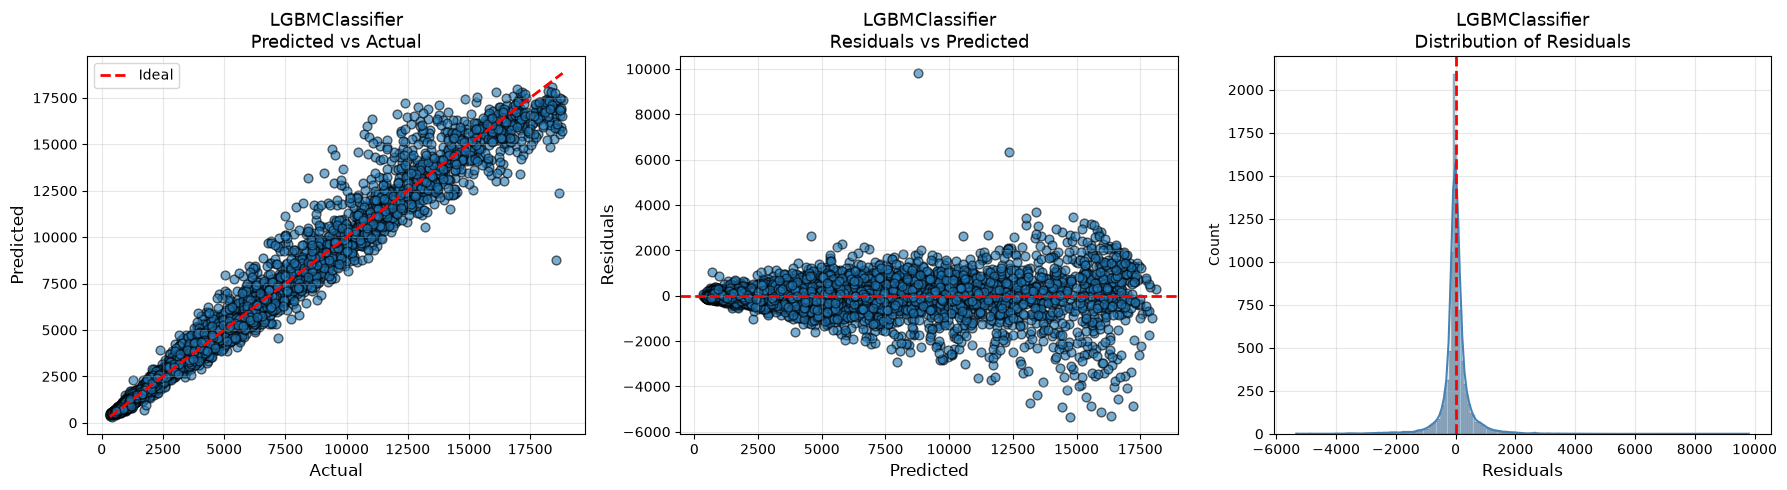

 Regression Report: LGBMClassifier
MAE   : 277.7982
MSE   : 295735.6919
RMSE  : 543.8159
R²    : 0.9815
MAPE  : 7.89%
MedAE : 118.1323


In [37]:
# Train your model
lgbm = LGBMRegressor(random_state=SEED)
lgbm.fit(X_train_preprocessed, y_train)

# Get predictions
y_pred = lgbm.predict(X_val_preprocessed)

# Evaluate
lgbm_metrics = evaluate_regression(
    y_test=y_val,
    y_pred=y_pred,
    model_name="LGBMClassifier"
)

Метрики:
- R2 = 0.9815 - лучший результат среди всех моделей.
- MAE ~278, RMSE ~544 - чуть лучше Random Forest по RMSE.
- MAPE ~7.9% - немного выше, чем у Random Forest (6.6%), но всё равно отличный уровень.
- MedAE ~118 - чуть выше, чем у RandomForest.

Графики:
- Predicted vs Actual: Точки очень хорошо ложатся вдоль идеальной линии.
- Residuals vs Predicted: Остатки в целом центрированы около нуля, разброс ошибок умеренно растёт с увеличением предсказанной цены.
- Distribution of Residuals: Распределение ошибок близко к нормальному и сильно сконцентрировано около нуля.

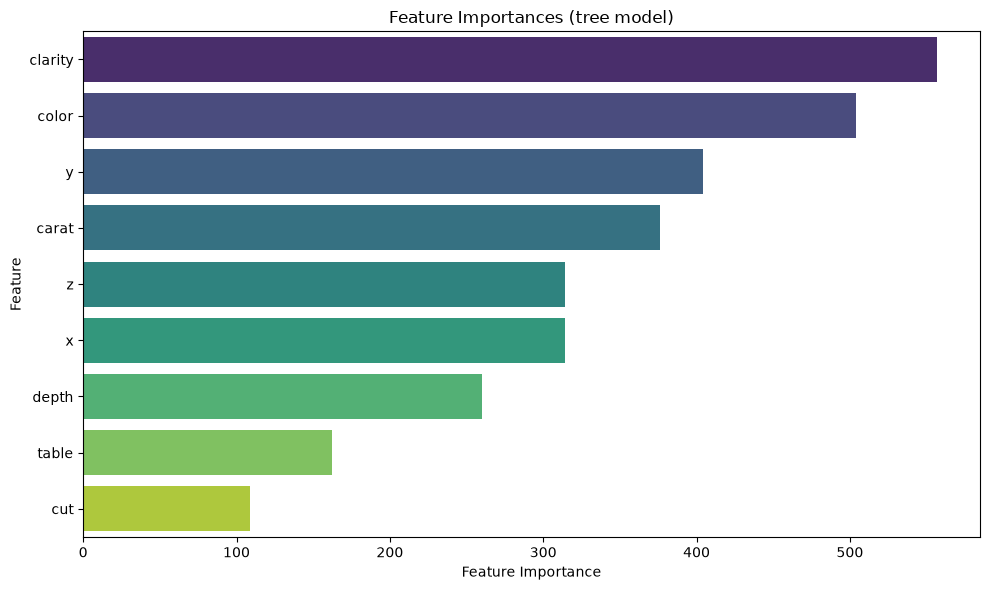

,Feature,Importance
2,clarity,557
1,color,504
7,y,404
3,carat,376
8,z,314
6,x,314
4,depth,260
5,table,162
0,cut,109


In [38]:
plot_feature_importance(lgbm, feature_names)

Заметно увеличение использование всех признаков, а за этим стоит учитывание сложных нелинейных закономерностей

### 6.6 Финальное сравнение метрик

In [53]:
final_metrics = {
    'dummy_regressor': dummy_classifier_metrics,
    'lin_reg': lin_reg_metrics,
    'decision_tree': decision_tree_metrics,
    'random_forest': random_forest_metrics,
    'lgbm': lgbm_metrics
}

result = pd.DataFrame(final_metrics.values(), index=final_metrics.keys())

In [54]:
result

,MAE,MSE,RMSE,R2,MAPE,MedAE
dummy_regressor,3038.270466,1.596093e+07,3995.113235,-0.000002,187.613421,2782.981404
lin_reg,802.902232,1.451520e+06,1204.790566,0.909058,43.005267,574.666777
decision_tree,338.641177,4.938740e+05,702.761698,0.969057,8.227693,123.000000
random_forest,275.511595,3.215008e+05,567.010427,0.979857,6.560133,100.990000
lgbm,277.798185,2.957357e+05,543.815862,0.981471,7.894220,118.132257


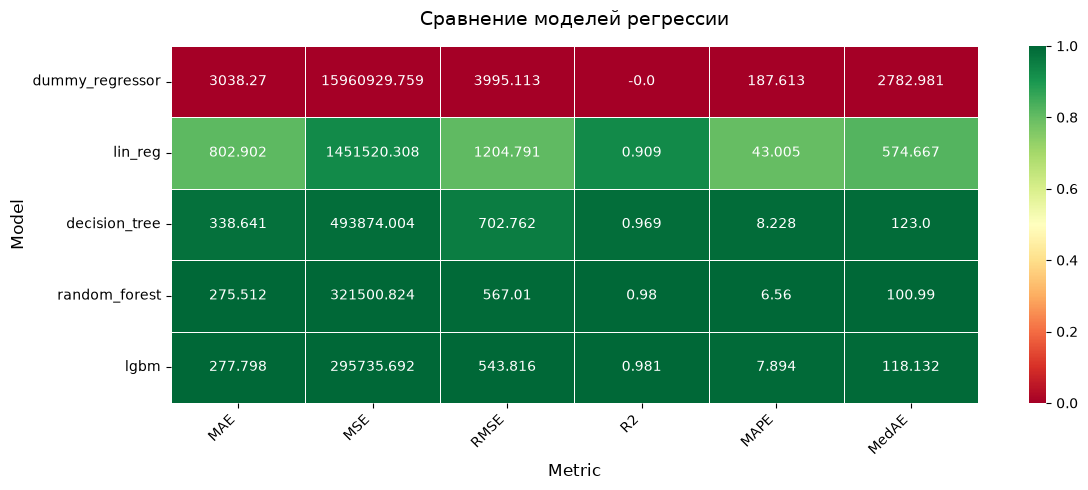

In [55]:
plot_metrics_heatmap(result, title='Сравнение моделей регрессии')

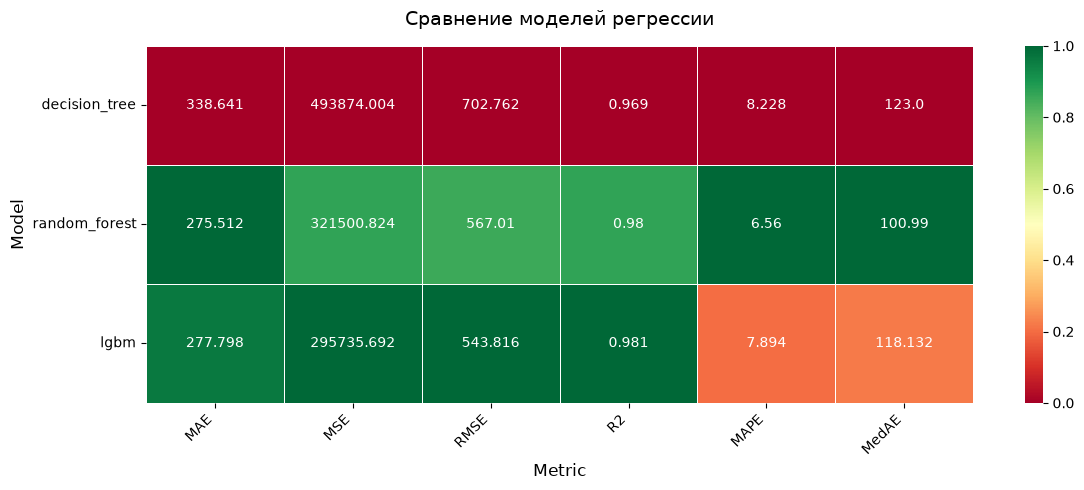

In [56]:
plot_metrics_heatmap(result.drop(['dummy_regressor', 'lin_reg']), title='Сравнение моделей регрессии')

Случайный лес и градиентный бустинг показывают наилучшие результаты. В сравнении:
- LightGBM немного лучше по R2 и RMSE
- Random Forest лучше по MAE, MAPE и MedAE